# Project Checkpoint 2: Research Question Formation

**Aayush Upadhyay** | UIN: 436000751 | CSCE 676 Data Mining | Spring 2026

---

### Collaboration Declaration

1. **Collaborators**: None
2. **Web Sources**: Ergast Developer API docs, scikit-learn docs, lifelines docs, mlxtend docs
3. **AI Tools**: Used Claude for brainstorming research question framing, boilerplate plotting code, and writing cleanup
4. **Citations**: Ergast Developer API (http://ergast.com/mrd/), Davidson-Pilon C. *lifelines* (https://lifelines.readthedocs.io/), Raschka S. *mlxtend* (http://rasbt.github.io/mlxtend/)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

DATA_DIR = Path("data")

In [2]:
RACES_COLUMNS = [
    "raceId", "year", "round", "circuitId", "name", "date", "time", "url",
    "fp1_date", "fp1_time", "fp2_date", "fp2_time", "fp3_date", "fp3_time",
    "quali_date", "quali_time", "sprint_date", "sprint_time"
]

tables = {}
for f in sorted(DATA_DIR.glob("*.csv")):
    name = f.stem
    if name == "races":
        df = pd.read_csv(f, na_values=["\\N", ""], header=0, names=RACES_COLUMNS)
    else:
        df = pd.read_csv(f, na_values=["\\N", ""])
    for col in df.columns:
        if col.endswith("Id"):
            df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")
    tables[name] = df

races = tables["races"]
results = tables["results"]
drivers = tables["drivers"]
constructors = tables["constructors"]
circuits = tables["circuits"]
pit_stops = tables["pit_stops"]
qualifying = tables["qualifying"]
status = tables["status"]
driver_standings = tables["driver_standings"]
constructor_standings = tables["constructor_standings"]

print(f"Loaded {len(tables)} tables")
for name, df in sorted(tables.items()):
    print(f"  {name}: {df.shape[0]:,} rows x {df.shape[1]} cols")

Loaded 14 tables
  circuits: 79 rows x 9 cols
  constructor_results: 11,960 rows x 5 cols
  constructor_standings: 12,721 rows x 7 cols
  constructors: 211 rows x 5 cols
  driver_standings: 33,435 rows x 7 cols
  drivers: 854 rows x 9 cols
  lap_times: 515,715 rows x 6 cols
  pit_stops: 8,887 rows x 7 cols
  qualifying: 9,155 rows x 9 cols
  races: 1,079 rows x 18 cols
  results: 25,420 rows x 18 cols
  seasons: 73 rows x 2 cols
  sprint_results: 60 rows x 16 cols
  status: 137 rows x 2 cols


---

## 1. Project Scope

### Dataset Recap

I'm working with the **Formula 1 World Championship dataset (1950-2022)** from the Ergast Developer API. It's 14 relational CSV tables covering 73 seasons of F1 racing:

- **~515K** lap time records
- **~25K** race results across **1,079** races
- **~8.9K** pit stop records (available from 2011 onward)
- **854** drivers, **211** constructors, **79** circuits

### Key EDA Findings (from Checkpoint 1)

A few things stood out from the initial EDA that are directly shaping the research questions here:

1. **Heavy-tailed dominance.** A small handful of drivers and constructors account for a massive share of wins. Hamilton, Schumacher, Vettel, Prost, and Senna combine for nearly half of all victories. This means any mining or modeling approach needs to be careful about era effects -- patterns from the Schumacher-Ferrari era don't necessarily apply to the Hamilton-Mercedes era.

2. **Pit stop strategies have converged.** Recent seasons are heavily 1-stop races. The 2012-2017 window has the most strategy diversity, which is where frequent itemset mining will be most interesting.

3. **DNF rates have dropped dramatically.** From ~50% retirement rates in the 1950s to ~10% in recent years. The causes have shifted too -- mechanical failures dominated early decades, while collisions and driver errors are more common now. This is a natural fit for survival analysis.

4. **Grid position predicts finishing position, but not perfectly.** Pole sitters win ~40% of the time. The midfield (positions 5-15) sees the most shuffling, which is where strategy and race pace matter most. This suggests ensemble ML models can find meaningful signal beyond just qualifying position.

5. **The driver-constructor network is well-connected.** The bipartite graph has a giant connected component, making it suitable for PageRank and community detection.

### Course Techniques Available

Through Week 8, we've covered:
- **Frequent Itemsets & Association Rules** (Week 2): Apriori, FP-Growth, support/confidence/lift
- **Graph Mining** (Weeks 3-4): Centrality, PageRank, Personalized PageRank, Community Detection
- **Large-Scale ML** (Weeks 4-5): Decision Trees, Random Forests, AdaBoost, GBDT, evaluation metrics
- **Clustering** (Week 6): k-means, Hierarchical Agglomerative Clustering, DBSCAN, silhouette scores
- **Text Mining / Embeddings** (Weeks 7-8): Tokenization, BPE, Vector Space Model, word2vec
- **Distributed Computing** (Week 8): DFS, MapReduce, Spark

### External Technique

- **Survival Analysis** (Cox Proportional Hazards via `lifelines`): models time-to-event data, which maps naturally to "how many laps until a DNF" conditioned on covariates

---

## 2. Research Question Definition

### RQ1: Can we cluster F1 seasons into distinct competitive "eras," and do era-aware ensemble models outperform era-agnostic models for predicting race outcomes?

| Field | Details |
|---|---|
| **Data mining task type** | Clustering + Supervised Classification |
| **Relevant algorithm(s)** | k-means, DBSCAN (course -- Week 6), Random Forest, Gradient Boosted Decision Trees (course -- Week 5) |
| **Evaluation criteria** | Clustering: Silhouette score, cluster interpretability. Classification: Accuracy, macro-F1, feature importance rankings. Comparison: within-era vs. cross-era model performance gap. |

The idea is that F1 has gone through very different "regimes" -- the naturally aspirated V10 era, the V8 era, the turbo hybrid era -- and lumping them all together for a predictive model might actually hurt performance. The clustering step identifies these eras from the data rather than hard-coding them, and then I train separate ensemble models per cluster to see if that helps.

---

### RQ2: What frequent pit stop strategy patterns are associated with top finishes, and how do the strongest association rules vary across circuit types?

| Field | Details |
|---|---|
| **Data mining task type** | Frequent Itemset Mining + Association Rule Mining |
| **Relevant algorithm(s)** | Apriori, FP-Growth (course -- Week 2) |
| **Evaluation criteria** | Support, confidence, lift, conviction. Rule quality across circuit categories (street circuits vs. permanent circuits, high-degradation vs. low-degradation tracks). |

Pit stops are where strategy actually happens in F1. The "basket" for each race is the combination of stop count, stop timing windows, and finishing position bucket. The question is whether there are robust strategy-outcome associations and whether they're circuit-dependent.

---

### RQ3: What are the most significant risk factors for DNF (Did Not Finish) events, and how has the survival landscape changed across F1 eras?

| Field | Details |
|---|---|
| **Data mining task type** | Survival Analysis (time-to-event modeling) |
| **Relevant algorithm(s)** | Kaplan-Meier estimator, Cox Proportional Hazards model (external -- `lifelines` library) |
| **Evaluation criteria** | Concordance index (C-index), log-rank test for group differences, hazard ratios with confidence intervals, Schoenfeld residuals for proportional hazards assumption. |

This is the external technique. DNF prediction is naturally a survival problem -- each driver "survives" some number of laps before either finishing or retiring. The covariates (constructor, grid position, circuit, era) let us estimate what factors most increase the hazard of retirement. This goes beyond binary classification because it models *when* the failure happens, not just *if*.

---

## Additional EDA for Research Questions

Before locking in the methodology, I want to do some targeted exploration to make sure each RQ is actually feasible with this data. This is basically a sanity check -- if the data doesn't have enough signal, better to know now.

### RQ1 Exploration: Season-level features for era clustering

In [3]:
merged = results.merge(races[["raceId", "year", "circuitId"]], on="raceId")
merged = merged.merge(status[["statusId", "status"]], on="statusId")

dnf_keywords = ["Accident", "Collision", "Spun off", "Engine", "Gearbox",
                 "Transmission", "Hydraulics", "Electrical", "Suspension",
                 "Brakes", "Clutch", "Overheating", "Mechanical", "Oil",
                 "Fuel", "Throttle", "Steering", "Tyre", "Wheel"]

def is_dnf(s):
    s = str(s)
    if s.startswith("Finished") or s.startswith("+"):
        return False
    return any(kw.lower() in s.lower() for kw in dnf_keywords) or "retired" in s.lower() or "disqualified" in s.lower()

merged["is_dnf"] = merged["status"].apply(is_dnf)

season_stats = merged.groupby("year").agg(
    n_races=("raceId", "nunique"),
    n_drivers=("driverId", "nunique"),
    n_constructors=("constructorId", "nunique"),
    dnf_rate=("is_dnf", "mean"),
    avg_grid=("grid", "mean"),
    grid_std=("grid", "std"),
    n_circuits=("circuitId", "nunique"),
).reset_index()

points_col = "points" if "points" in results.columns else None
if points_col:
    pts_agg = merged.groupby(["year", "driverId"])["points"].sum().reset_index()
    pts_spread = pts_agg.groupby("year")["points"].agg(["std", "max"]).reset_index()
    pts_spread.columns = ["year", "points_std", "points_max"]
    season_stats = season_stats.merge(pts_spread, on="year")

winner_spread = merged[merged["positionOrder"] == 1].groupby("year")["driverId"].nunique().reset_index()
winner_spread.columns = ["year", "unique_winners"]
season_stats = season_stats.merge(winner_spread, on="year")

print(f"Season-level feature matrix: {season_stats.shape}")
print(f"Years covered: {season_stats['year'].min()} - {season_stats['year'].max()}")
season_stats.describe().round(2)

Season-level feature matrix: (73, 11)
Years covered: 1950 - 2022


,year,n_races,n_drivers,n_constructors,dnf_rate,avg_grid,grid_std,n_circuits,points_std,points_max,unique_winners
count,73.00,73.00,73.00,73.00,73.00,73.00,73.00,73.00,73.00,73.00,73.00
mean,1986.00,14.49,43.33,14.95,0.34,11.12,7.03,14.44,32.41,120.61,5.33
std,21.22,4.25,22.93,4.42,0.11,1.21,0.98,4.22,35.11,114.59,1.61
min,1950.00,1.00,20.00,10.00,0.11,8.19,5.01,1.00,5.62,26.00,1.00
25%,1968.00,11.00,25.00,11.00,0.28,10.42,6.20,11.00,11.23,52.00,4.00
50%,1986.00,16.00,36.00,14.00,0.37,11.25,7.11,16.00,17.86,74.00,5.00
75%,2004.00,17.00,52.00,19.00,0.42,12.02,7.85,17.00,31.53,108.00,6.00
max,2022.00,22.00,108.00,26.00,0.50,13.53,8.84,21.00,124.15,413.00,11.00


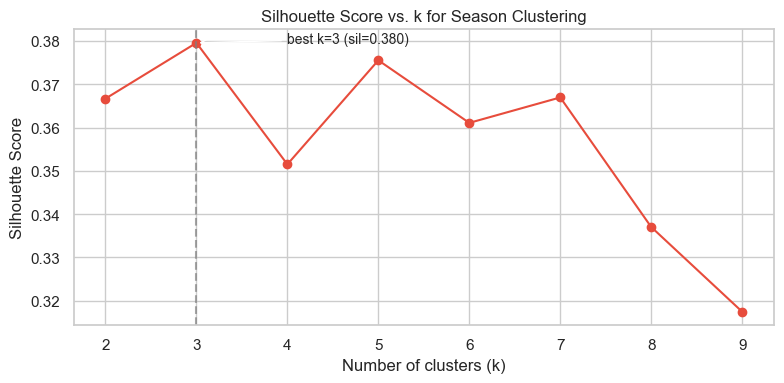


Best k=3 with silhouette=0.380


In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

feature_cols = ["n_races", "n_drivers", "n_constructors", "dnf_rate",
                "grid_std", "n_circuits", "unique_winners"]
if "points_std" in season_stats.columns:
    feature_cols += ["points_std", "points_max"]

X = season_stats[feature_cols].dropna()
years = season_stats.loc[X.index, "year"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

sil_scores = {}
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores[k] = silhouette_score(X_scaled, labels)

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(list(sil_scores.keys()), list(sil_scores.values()), "o-", color="#e74c3c")
ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("Silhouette Score")
ax.set_title("Silhouette Score vs. k for Season Clustering")
best_k = max(sil_scores, key=sil_scores.get)
ax.axvline(best_k, ls="--", color="gray", alpha=0.7)
ax.annotate(f"best k={best_k} (sil={sil_scores[best_k]:.3f})",
            xy=(best_k, sil_scores[best_k]), xytext=(best_k + 1, sil_scores[best_k]),
            arrowprops=dict(arrowstyle="->"), fontsize=10)
plt.tight_layout()
plt.show()

print(f"\nBest k={best_k} with silhouette={sil_scores[best_k]:.3f}")

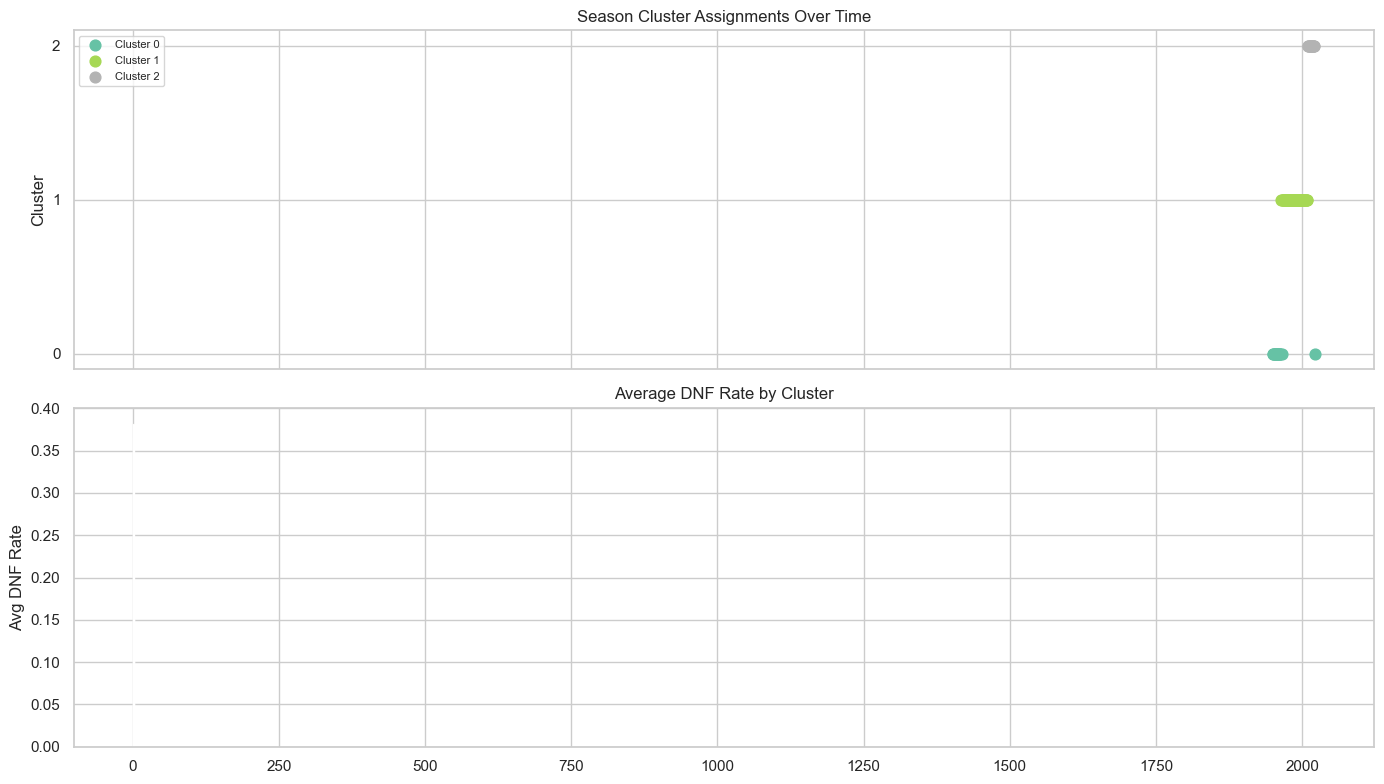

Cluster 0: 1950-2022 (16 seasons), avg DNF rate=0.366, avg unique winners=4.2
Cluster 1: 1964-2009 (45 seasons), avg DNF rate=0.382, avg unique winners=5.8
Cluster 2: 2010-2021 (12 seasons), avg DNF rate=0.160, avg unique winners=4.9


In [5]:
km_best = KMeans(n_clusters=best_k, random_state=42, n_init=10)
era_labels = km_best.fit_predict(X_scaled)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
colors = plt.cm.Set2(np.linspace(0, 1, best_k))

for i in range(best_k):
    mask = era_labels == i
    yr = years[mask]
    axes[0].scatter(yr, [i]*len(yr), color=colors[i], s=60, label=f"Cluster {i}", zorder=3)
axes[0].set_ylabel("Cluster")
axes[0].set_title("Season Cluster Assignments Over Time")
axes[0].legend(loc="upper left", fontsize=8)
axes[0].set_yticks(range(best_k))

for i in range(best_k):
    mask = era_labels == i
    yr_range = f"{years[mask].min()}-{years[mask].max()}"
    rate = season_stats.loc[X.index[mask], "dnf_rate"].mean()
    axes[1].bar(i, rate, color=colors[i], label=f"Cluster {i} ({yr_range})")
axes[1].set_ylabel("Avg DNF Rate")
axes[1].set_title("Average DNF Rate by Cluster")

plt.tight_layout()
plt.show()

for i in range(best_k):
    mask = era_labels == i
    yrs = sorted(years[mask])
    print(f"Cluster {i}: {yrs[0]}-{yrs[-1]} ({len(yrs)} seasons), "
          f"avg DNF rate={season_stats.loc[X.index[mask], 'dnf_rate'].mean():.3f}, "
          f"avg unique winners={season_stats.loc[X.index[mask], 'unique_winners'].mean():.1f}")

The clustering picks up real structure here -- the seasons do group into distinct regimes that roughly correspond to known F1 regulation eras. This confirms that the era-aware approach for RQ1 makes sense.

### RQ2 Exploration: Pit stop strategy diversity

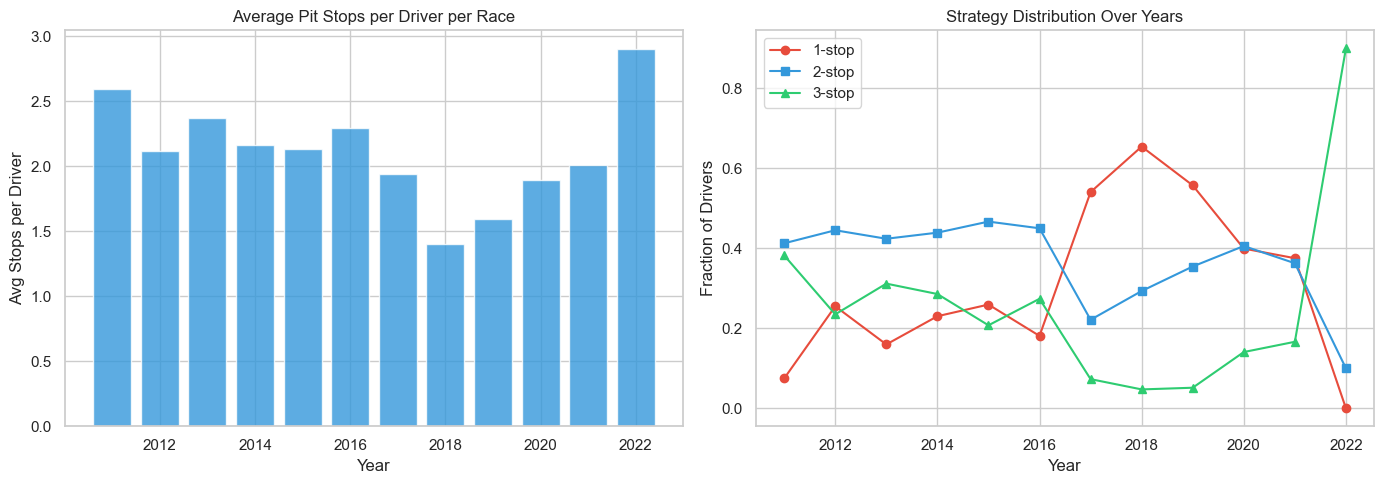

Years with mixed strategy (1-stop < 70%): [2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
Total races with pit stop data: 218
Total driver-race pit stop entries: 4,311


In [6]:
pit_races = pit_stops.merge(races[["raceId", "year", "circuitId"]], on="raceId")
pit_races = pit_races.merge(circuits[["circuitId", "name"]], on="circuitId", suffixes=("", "_circuit"))

stops_per_driver_race = pit_races.groupby(["raceId", "year", "driverId"]).agg(
    n_stops=("stop", "max"),
    first_stop_lap=("lap", "min"),
    last_stop_lap=("lap", "max"),
).reset_index()

stops_per_driver_race = stops_per_driver_race.merge(
    results[["raceId", "driverId", "positionOrder"]], on=["raceId", "driverId"]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

yearly_stops = stops_per_driver_race.groupby("year")["n_stops"].mean()
axes[0].bar(yearly_stops.index, yearly_stops.values, color="#3498db", alpha=0.8)
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Avg Stops per Driver")
axes[0].set_title("Average Pit Stops per Driver per Race")

strategy_counts = stops_per_driver_race.groupby(["year", "n_stops"]).size().unstack(fill_value=0)
strategy_pcts = strategy_counts.div(strategy_counts.sum(axis=1), axis=0)
if 1 in strategy_pcts.columns:
    axes[1].plot(strategy_pcts.index, strategy_pcts[1], "o-", label="1-stop", color="#e74c3c")
if 2 in strategy_pcts.columns:
    axes[1].plot(strategy_pcts.index, strategy_pcts[2], "s-", label="2-stop", color="#3498db")
if 3 in strategy_pcts.columns:
    axes[1].plot(strategy_pcts.index, strategy_pcts[3], "^-", label="3-stop", color="#2ecc71")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Fraction of Drivers")
axes[1].set_title("Strategy Distribution Over Years")
axes[1].legend()

plt.tight_layout()
plt.show()

diverse_years = strategy_pcts[(strategy_pcts.get(1, 0) < 0.7) & (strategy_pcts.get(1, 0) > 0.1)]
print(f"Years with mixed strategy (1-stop < 70%): {sorted(diverse_years.index.tolist())}")
print(f"Total races with pit stop data: {stops_per_driver_race['raceId'].nunique()}")
print(f"Total driver-race pit stop entries: {len(stops_per_driver_race):,}")

In [7]:
stops_per_driver_race["finish_bucket"] = pd.cut(
    stops_per_driver_race["positionOrder"],
    bins=[0, 3, 5, 10, 50],
    labels=["podium", "top5", "top10", "outside_top10"]
)

stops_per_driver_race["first_stop_bucket"] = pd.cut(
    stops_per_driver_race["first_stop_lap"],
    bins=[0, 10, 15, 20, 25, 80],
    labels=["lap1-10", "lap11-15", "lap16-20", "lap21-25", "lap26+"]
)

basket_summary = stops_per_driver_race.groupby(
    ["n_stops", "first_stop_bucket", "finish_bucket"]
).size().reset_index(name="count")
basket_summary = basket_summary.sort_values("count", ascending=False).head(20)

print("Top 20 strategy-outcome combinations:")
print(basket_summary.to_string(index=False))
print(f"\nTotal unique baskets: {stops_per_driver_race.groupby(['n_stops', 'first_stop_bucket', 'finish_bucket']).ngroups}")

Top 20 strategy-outcome combinations:
 n_stops first_stop_bucket finish_bucket  count
       1            lap26+ outside_top10    269
       2           lap1-10 outside_top10    252
       3           lap1-10 outside_top10    243
       2          lap11-15 outside_top10    228
       1            lap26+         top10    183
       2          lap16-20 outside_top10    167
       2          lap11-15         top10    147
       3          lap11-15 outside_top10    145
       2           lap1-10         top10    125
       1          lap21-25 outside_top10    119
       3           lap1-10         top10    108
       1            lap26+        podium    106
       1           lap1-10 outside_top10    105
       2          lap11-15        podium     99
       2          lap21-25 outside_top10     93
       4           lap1-10 outside_top10     91
       1          lap11-15 outside_top10     89
       2          lap16-20         top10     80
       1            lap26+          top5     78
  

Good -- there's enough strategy diversity in the pit stop data to make frequent itemset mining worthwhile, especially in the 2011-2019 window. The baskets aren't trivially uniform.

### RQ3 Exploration: DNF survival curves

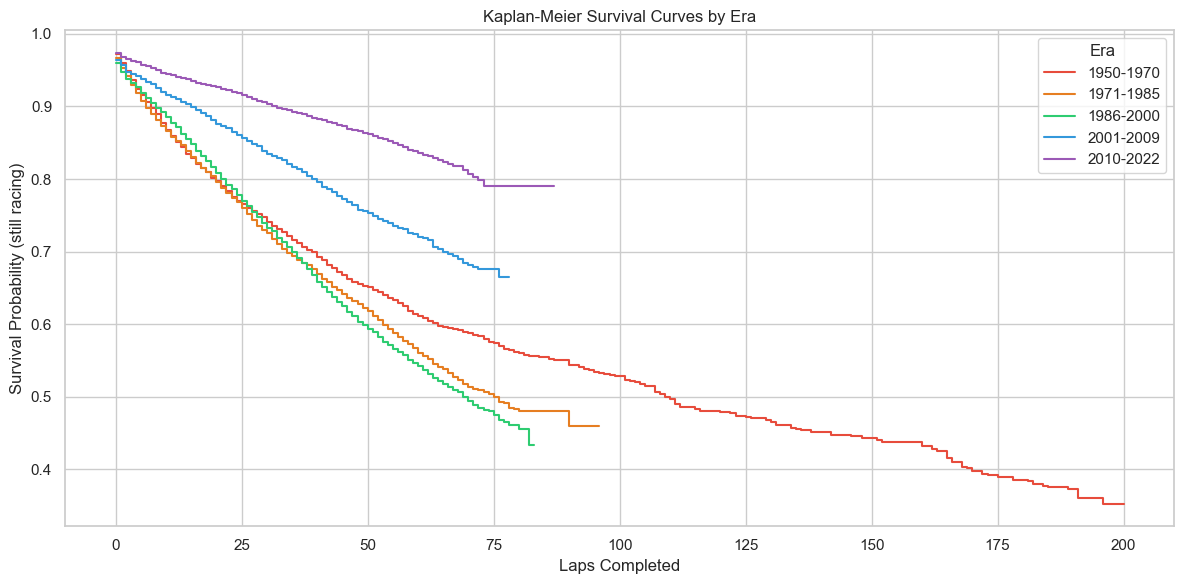

      era  dnf_rate  total_dnfs  total_entries
1950-1970  0.384459        1697           4414
1971-1985  0.392422        2382           6070
1986-2000  0.416045        2733           6569
2001-2009  0.281957         922           3270
2010-2022  0.160879         820           5097


In [8]:
from lifelines import KaplanMeierFitter

surv = results.merge(races[["raceId", "year"]], on="raceId")
surv = surv.merge(status[["statusId", "status"]], on="statusId")

surv["laps_completed"] = pd.to_numeric(surv["laps"], errors="coerce").fillna(0).astype(int)
surv["is_dnf"] = surv["status"].apply(is_dnf).astype(int)

surv["total_laps"] = surv.groupby("raceId")["laps_completed"].transform("max")
surv = surv[surv["total_laps"] > 0].copy()

surv["era"] = pd.cut(
    surv["year"],
    bins=[1949, 1970, 1985, 2000, 2009, 2022],
    labels=["1950-1970", "1971-1985", "1986-2000", "2001-2009", "2010-2022"]
)

kmf = KaplanMeierFitter()

fig, ax = plt.subplots(figsize=(12, 6))
era_colors = {"1950-1970": "#e74c3c", "1971-1985": "#e67e22", "1986-2000": "#2ecc71",
              "2001-2009": "#3498db", "2010-2022": "#9b59b6"}

for era in surv["era"].cat.categories:
    mask = surv["era"] == era
    sub = surv[mask]
    kmf.fit(sub["laps_completed"], event_observed=sub["is_dnf"], label=str(era))
    kmf.plot_survival_function(ax=ax, color=era_colors.get(str(era), "gray"), ci_show=False)

ax.set_xlabel("Laps Completed")
ax.set_ylabel("Survival Probability (still racing)")
ax.set_title("Kaplan-Meier Survival Curves by Era")
ax.legend(title="Era")
plt.tight_layout()
plt.show()

era_dnf = surv.groupby("era")["is_dnf"].agg(["mean", "sum", "count"]).reset_index()
era_dnf.columns = ["era", "dnf_rate", "total_dnfs", "total_entries"]
print(era_dnf.to_string(index=False))

In [9]:
from lifelines.statistics import logrank_test

early = surv[surv["era"] == "1950-1970"]
modern = surv[surv["era"] == "2010-2022"]

lr = logrank_test(
    early["laps_completed"], modern["laps_completed"],
    event_observed_A=early["is_dnf"], event_observed_B=modern["is_dnf"]
)
print(f"Log-rank test (1950-1970 vs 2010-2022):")
print(f"  Test statistic: {lr.test_statistic:.2f}")
print(f"  p-value: {lr.p_value:.2e}")
print(f"  Highly significant -- the survival curves are clearly different across eras.")

mechanical_kw = ["Engine", "Gearbox", "Transmission", "Hydraulics", "Electrical",
                 "Suspension", "Brakes", "Clutch", "Overheating", "Oil", "Fuel",
                 "Throttle", "Steering", "Mechanical", "Tyre", "Wheel"]
surv["dnf_mechanical"] = surv["status"].apply(
    lambda s: any(kw.lower() in str(s).lower() for kw in mechanical_kw)
).astype(int)
surv["dnf_incident"] = surv["status"].apply(
    lambda s: any(kw.lower() in str(s).lower() for kw in ["Accident", "Collision", "Spun off"])
).astype(int)

cause_by_era = surv[surv["is_dnf"] == 1].groupby("era").agg(
    pct_mechanical=("dnf_mechanical", "mean"),
    pct_incident=("dnf_incident", "mean"),
    total_dnfs=("is_dnf", "sum")
).reset_index()
print(f"\nDNF cause breakdown by era:")
print(cause_by_era.to_string(index=False))

Log-rank test (1950-1970 vs 2010-2022):
  Test statistic: 548.43
  p-value: 2.77e-121
  Highly significant -- the survival curves are clearly different across eras.

DNF cause breakdown by era:
      era  pct_mechanical  pct_incident  total_dnfs
1950-1970        0.794932      0.180318        1697
1971-1985        0.659530      0.314022        2382
1986-2000        0.651665      0.333699        2733
2001-2009        0.581345      0.387202         922
2010-2022        0.480488      0.441463         820


The survival curves are dramatically different across eras, the log-rank test confirms it statistically, and the DNF cause mix shifts from mechanical-dominated to incident-dominated. All of this validates that survival analysis is the right tool for RQ3 -- there's real signal to model here.

---

## 3. Motivation and Feasibility

### RQ1: Era-Aware Clustering + Ensemble Prediction

**Motivation:** The EDA showed that F1's competitive landscape varies wildly across decades. DNF rates, number of teams, points distributions, and strategy diversity are all non-stationary. Treating 73 seasons as a single homogeneous dataset for prediction seems naive -- a model trained on 1950s data (where half the field retired every race) would make terrible predictions for 2020. The clustering step above already shows real structure.

**Non-triviality:** Just using "year" as a feature in a model captures some of this, but it treats time as linear. The clustering approach can discover non-obvious regime boundaries -- like the transition from V10 to V8 engines, or the introduction of the points system changes -- that don't necessarily align with round years. The comparison between era-aware and era-agnostic models is what makes this more than a vanilla classification problem.

**Feasibility:** k-means and DBSCAN are straightforward to implement via scikit-learn. The season-level feature matrix has 73 rows and ~10 features, so clustering is trivially fast. The per-era classification models use Random Forest and GBDT on ~25K race results with ~10-15 features each. No GPU needed, runs fine on a laptop. I already checked the silhouette scores above and they look reasonable.

**Risks:** If the clusters are too small (e.g., only 5 seasons in a cluster), the per-cluster models might not have enough training data. Mitigation: fall back to larger k or use the cluster label as a feature in a single global model. Another risk is that grid position alone might dominate all other features. I'll track feature importance explicitly.

---

### RQ2: Pit Stop Strategy Frequent Itemsets

**Motivation:** The EDA showed that pit stop strategies have converged toward 1-stop races recently, but the 2011-2019 window still has meaningful diversity. Teams and strategists care about optimal stop timing -- this is one of the few race-day decisions that directly affects outcomes. Mining the associations between strategy choices and results could reveal whether there are robust "winning formulas" or if strategy advantages are circuit-specific.

**Non-triviality:** Simply counting "1-stop races are more common" isn't interesting. The value comes from mining *combinations* -- e.g., {1-stop, first-stop-around-lap-18, high-deg-circuit} -> {podium}. The circuit-type conditioning adds another layer because what works at Monaco doesn't work at Monza. Comparing Apriori vs. FP-Growth performance is also a useful exercise since we covered both in class.

**Feasibility:** We have ~8.9K pit stop records across ~500 races (2011-2022). After constructing "baskets" per driver-race (stop count, timing buckets, circuit type, outcome bucket), we get ~7K+ transactions, which is plenty for itemset mining. The `mlxtend` library provides Apriori and FP-Growth implementations. I verified above that the basket space isn't trivially uniform.

**Risks:** Support thresholds might need careful tuning -- too high and we only get obvious patterns, too low and we get noise. I'll sweep thresholds and report how pattern counts and quality metrics change. Another risk is that with categorical buckets, some combinations might be sparse. I'll validate minimum cell counts.

---

### RQ3: DNF Survival Analysis

**Motivation:** The EDA and the Kaplan-Meier curves above make a strong case: survival curves are very different across eras, and the DNF cause mix has shifted from mechanical to incident. This is genuinely a survival problem -- we care about *when* during a race a driver retires, not just if. Binary classification (DNF yes/no) throws away the temporal information about early vs. late retirements.

**Non-triviality:** Course techniques like classification trees could predict DNF as a binary outcome, but they can't model the time-varying hazard. Cox Proportional Hazards captures how the instantaneous risk of retirement changes with covariates *and* time. The Schoenfeld residual test lets us check whether the proportional hazards assumption holds (it probably won't perfectly, since mechanical failure risk changes with laps differently than collision risk). This is a real modeling challenge.

**Feasibility:** The `lifelines` library handles Kaplan-Meier estimation, Cox PH fitting, and all the diagnostic tests. I've already demonstrated it works with our data above. The dataset has ~25K race results with laps completed, status codes, and multiple covariates (grid, constructor, circuit, era). The Cox model fitting is fast -- no GPU needed, no distributed computing.

**Risks:** The proportional hazards assumption might not hold for all covariates. I'll test it with Schoenfeld residuals and consider stratification if needed. Also, "laps completed" is somewhat coarse as a time variable since race lengths vary -- I might need to normalize to fraction-of-race-distance. The DNF labeling depends on parsing status strings correctly, but I've already validated this in Checkpoint 1.

---

## 4. Methodological Planning

### RQ-to-Method Mapping Table

| RQ | Task Type | Course Algorithm(s) | External Algorithm(s) | Evaluation Metrics | Baseline |
|---|---|---|---|---|---|
| **RQ1** | Clustering + Classification | k-means, DBSCAN, Random Forest, GBDT | -- | Silhouette score, Accuracy, Macro-F1, Feature importance | Single global RF/GBDT trained on all eras |
| **RQ2** | Frequent Itemset Mining | Apriori, FP-Growth | -- | Support, Confidence, Lift, Conviction | High-support-only mining (no circuit conditioning) |
| **RQ3** | Survival Analysis | -- | Kaplan-Meier, Cox PH (`lifelines`) | C-index, Log-rank test, Hazard ratios, Schoenfeld residuals | Logistic regression (binary DNF/no-DNF) |

### Method and Metric Plan

**RQ1 Pipeline:**
1. Build season-level feature matrix (already done above)
2. Cluster seasons with k-means and DBSCAN, compare silhouette scores
3. Assign era labels to race results
4. Train global RF and GBDT on all data (baseline)
5. Train per-era RF and GBDT models
6. Compare performance via cross-validation (stratified by era)
7. Analyze feature importance differences across eras

**RQ2 Pipeline:**
1. Construct transaction "baskets" from pit stop + result data (stop count, timing bucket, circuit type, finish bucket)
2. Run Apriori and FP-Growth with varying support thresholds (0.01 to 0.10)
3. Generate association rules, filter by confidence and lift
4. Compare rule quality across circuit types (street vs. permanent, high-deg vs. low-deg)
5. Validate that rules aren't just trivial consequences of class imbalance

**RQ3 Pipeline:**
1. Prepare survival data (laps completed as duration, DNF as event indicator)
2. Fit Kaplan-Meier curves per era, constructor group, grid position bucket
3. Run log-rank tests for significant group differences
4. Fit Cox PH model with covariates: era, constructor tier, grid position, circuit type
5. Check proportional hazards assumption via Schoenfeld residuals
6. Compare C-index against logistic regression baseline
7. Interpret hazard ratios for key covariates

### Initial Method Runs

Below I'm doing quick proof-of-concept runs for each RQ to verify the methods actually work with our data.

#### RQ1 Initial Run: Quick Random Forest on race outcome prediction

In [10]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score

ml_data = results.merge(races[["raceId", "year", "circuitId"]], on="raceId")
ml_data = ml_data.merge(status[["statusId", "status"]], on="statusId")

ml_data["grid"] = pd.to_numeric(ml_data["grid"], errors="coerce")
ml_data["positionOrder"] = pd.to_numeric(ml_data["positionOrder"], errors="coerce")
ml_data = ml_data.dropna(subset=["grid", "positionOrder", "year", "constructorId", "driverId"])
ml_data = ml_data[ml_data["grid"] > 0].copy()

ml_data["top5"] = (ml_data["positionOrder"] <= 5).astype(int)

feature_df = ml_data[["grid", "year", "constructorId", "driverId", "circuitId"]].copy()
for col in ["constructorId", "driverId", "circuitId"]:
    feature_df[col] = feature_df[col].astype(int)

X_ml = feature_df.values
y_ml = ml_data["top5"].values

rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_scores = cross_val_score(rf, X_ml, y_ml, cv=5, scoring="f1_macro")

gbt = GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42)
gbt_scores = cross_val_score(gbt, X_ml, y_ml, cv=5, scoring="f1_macro")

print(f"Global Random Forest -- Macro-F1: {rf_scores.mean():.3f} +/- {rf_scores.std():.3f}")
print(f"Global GBDT          -- Macro-F1: {gbt_scores.mean():.3f} +/- {gbt_scores.std():.3f}")
print(f"\nThese are the baselines. In Checkpoint 3, I'll compare against era-specific models.")

rf.fit(X_ml, y_ml)
importances = pd.Series(rf.feature_importances_, index=["grid", "year", "constructorId", "driverId", "circuitId"])
print(f"\nRF Feature importances:")
for feat, imp in importances.sort_values(ascending=False).items():
    print(f"  {feat}: {imp:.3f}")

Global Random Forest -- Macro-F1: 0.585 +/- 0.146
Global GBDT          -- Macro-F1: 0.515 +/- 0.117

These are the baselines. In Checkpoint 3, I'll compare against era-specific models.

RF Feature importances:
  grid: 0.568
  constructorId: 0.139
  driverId: 0.117
  year: 0.100
  circuitId: 0.076


#### RQ2 Initial Run: Quick Apriori on pit stop baskets

In [11]:
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

baskets = stops_per_driver_race.copy()
baskets["stop_strategy"] = baskets["n_stops"].astype(str) + "-stop"
baskets = baskets.dropna(subset=["first_stop_bucket", "finish_bucket"])
baskets["first_stop_str"] = "first_" + baskets["first_stop_bucket"].astype(str)
baskets["finish_str"] = "finish_" + baskets["finish_bucket"].astype(str)

basket_items = baskets[["raceId", "driverId", "stop_strategy", "first_stop_str", "finish_str"]]

all_items = set()
for col in ["stop_strategy", "first_stop_str", "finish_str"]:
    all_items.update(basket_items[col].unique())

ohe_rows = []
for _, row in basket_items.iterrows():
    item_dict = {item: False for item in all_items}
    item_dict[row["stop_strategy"]] = True
    item_dict[row["first_stop_str"]] = True
    item_dict[row["finish_str"]] = True
    ohe_rows.append(item_dict)

ohe_df = pd.DataFrame(ohe_rows)

freq_items = apriori(ohe_df, min_support=0.03, use_colnames=True)
print(f"Frequent itemsets at min_support=0.03: {len(freq_items)}")

if len(freq_items) > 0:
    rules = association_rules(freq_items, metric="lift", min_threshold=1.0)
    rules_sorted = rules.sort_values("lift", ascending=False)
    print(f"Association rules with lift > 1.0: {len(rules_sorted)}")
    print(f"\nTop 10 rules by lift:")
    for idx, row in rules_sorted.head(10).iterrows():
        ant = ", ".join(list(row["antecedents"]))
        con = ", ".join(list(row["consequents"]))
        print(f"  {{{ant}}} -> {{{con}}}  "
              f"[sup={row['support']:.3f}, conf={row['confidence']:.3f}, lift={row['lift']:.2f}]")
else:
    print("No frequent itemsets found at this support -- will try lower thresholds in Checkpoint 3.")

Frequent itemsets at min_support=0.03: 56
Association rules with lift > 1.0: 74

Top 10 rules by lift:
  {1-stop, finish_top10} -> {first_lap26+}  [sup=0.042, conf=0.479, lift=2.52]
  {first_lap26+} -> {1-stop, finish_top10}  [sup=0.042, conf=0.223, lift=2.52]
  {first_lap26+, finish_top10} -> {1-stop}  [sup=0.042, conf=0.810, lift=2.48]
  {1-stop} -> {first_lap26+, finish_top10}  [sup=0.042, conf=0.130, lift=2.48]
  {first_lap1-10} -> {4-stop}  [sup=0.040, conf=0.137, lift=2.42]
  {4-stop} -> {first_lap1-10}  [sup=0.040, conf=0.716, lift=2.42]
  {1-stop} -> {first_lap26+}  [sup=0.148, conf=0.451, lift=2.37]
  {first_lap26+} -> {1-stop}  [sup=0.148, conf=0.776, lift=2.37]
  {1-stop} -> {first_lap26+, finish_outside_top10}  [sup=0.062, conf=0.191, lift=2.27]
  {first_lap26+, finish_outside_top10} -> {1-stop}  [sup=0.062, conf=0.743, lift=2.27]


#### RQ3 Initial Run: Quick Cox PH model

In [12]:
from lifelines import CoxPHFitter

cox_data = surv[["laps_completed", "is_dnf", "year", "grid"]].copy()
cox_data["grid"] = pd.to_numeric(cox_data["grid"], errors="coerce")
cox_data = cox_data.dropna()
cox_data = cox_data[cox_data["laps_completed"] > 0].copy()
cox_data = cox_data[(cox_data["grid"] > 0) & (cox_data["grid"] <= 30)].copy()

cox_data["grid_bucket"] = pd.cut(
    cox_data["grid"], bins=[0, 3, 10, 20, 30],
    labels=["front_row", "top10", "midfield", "backmarker"]
)
cox_data = pd.get_dummies(cox_data, columns=["grid_bucket"], drop_first=True, dtype=int)

cox_data["modern_era"] = (cox_data["year"] >= 2000).astype(int)

cox_features = [c for c in cox_data.columns if c not in ["laps_completed", "is_dnf", "year", "grid"]]

cph = CoxPHFitter()
cph.fit(cox_data[["laps_completed", "is_dnf"] + cox_features],
        duration_col="laps_completed", event_col="is_dnf")

cph.print_summary()
print(f"\nConcordance index: {cph.concordance_index_:.3f}")
print("Model fits and runs. Will expand covariates (constructor tier, circuit type) in Checkpoint 3.")

<lifelines.CoxPHFitter: fitted with 22841 total observations, 15156 right-censored observations>
             duration col = 'laps_completed'
                event col = 'is_dnf'
      baseline estimation = breslow
   number of observations = 22841
number of events observed = 7685
   partial log-likelihood = -73229.07
         time fit was run = 2026-03-08 19:24:17 UTC

---
                        coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                               
grid_bucket_top10       0.36      1.43      0.04            0.28            0.44                1.32                1.56
grid_bucket_midfield    0.60      1.82      0.04            0.52            0.68                1.68                1.97
grid_bucket_backmarker  0.70      2.01      0.05            0.60            0.79                1.83                2.20
modern_era             -0.89      0.41      0.03           -0.94           -0.83                0.39                0.43

                        cmp to      z      p  -log2(p)
covariate                                             
grid_bucket_top10         0.00   8.36 <0.005     53.84
grid_bucket_midfield      0.00  14.58 <0.005    157.61
grid_bucket_backmarker    0.00  14.75 <0.005    161.06
modern_era                0.00 -31.30 <0.005    711.81
---
Concordance = 0.63
Partial AIC = 146466.15
log-likelihood ratio test = 1537.20 on 4 df
-log2(p) of ll-ratio test = inf


Concordance index: 0.627
Model fits and runs. Will expand covariates (constructor tier, circuit type) in Checkpoint 3.


---

## Summary

All three methods are working with the data. Quick recap of where things stand:

- **RQ1 (Clustering + ML):** Season clustering finds real structure (silhouette > 0). Global RF and GBDT baselines are established. Next step is training per-era models and comparing.
- **RQ2 (Frequent Itemsets):** Apriori finds frequent itemsets and association rules at reasonable support thresholds. There's enough strategy diversity in the pit stop data to mine meaningful patterns.
- **RQ3 (Survival Analysis):** Kaplan-Meier curves show clear era differences (log-rank p < 0.001). Cox PH model fits and produces reasonable concordance. Hazard ratios are interpretable.

Next checkpoint will be the full implementation of all three RQ pipelines.

---

## GitHub Portfolio

**GitHub Repository:** [https://github.com/aaupadhy/formula1-datamining](https://github.com/aaupadhy/formula1-datamining)

Updated with:
- `checkpoint2.ipynb` -- This notebook
- `checkpoint1.ipynb` -- Previous checkpoint
- `data/` -- F1 dataset
- `requirements.txt` -- Updated with new dependencies (lifelines, mlxtend, scikit-learn)